# Real-Time Emotion Detection

# CNN Model Training

## Objectives

- Load datasets
- Build CNN model
- Train the model
- Plot Accuracy and Loss Curves
- Save the trained model

In [8]:
import tensorflow as tf
from tensorflow.keras import layers, models
import matplotlib.pyplot as plt

In [9]:
IMAGE_SIZE = (48,48)
BATCH_SIZE = 32
EPOCHS = 20

In [10]:
train_dataset = tf.keras.utils.image_dataset_from_directory(
    "../data/train",
    image_size=IMAGE_SIZE,
    batch_size=BATCH_SIZE,
    color_mode="grayscale"
)

test_dataset = tf.keras.utils.image_dataset_from_directory(
    "../data/test",
    image_size=IMAGE_SIZE,
    batch_size=BATCH_SIZE,
    color_mode="grayscale"
)

Found 28708 files belonging to 7 classes.


KeyboardInterrupt: 

In [ ]:
normalization_layer = layers.Rescaling(1./255)

train_dataset = train_dataset.map(
    lambda x, y: (normalization_layer(x), y)
)

test_dataset = test_dataset.map(
    lambda x, y: (normalization_layer(x), y)
)

In [ ]:
model = models.Sequential([

    layers.Input(shape=(48,48,1)),

    layers.Conv2D(32,(3,3),activation="relu"),
    layers.MaxPooling2D(),

    layers.Conv2D(64,(3,3),activation="relu"),
    layers.MaxPooling2D(),

    layers.Conv2D(128,(3,3),activation="relu"),
    layers.MaxPooling2D(),

    layers.Flatten(),

    layers.Dense(128,activation="relu"),

    layers.Dropout(0.5),

    layers.Dense(7,activation="softmax")

])

In [ ]:
model.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

In [ ]:
history = model.fit(
    train_dataset,
    validation_data=test_dataset,
    epochs=EPOCHS
)

Epoch 1/20
898/898 [==============================] - 211s 233ms/step - loss: 1.7514 - accuracy: 0.2851 - val_loss: 1.5581 - val_accuracy: 0.3915
Epoch 2/20
898/898 [==============================] - 128s 142ms/step - loss: 1.5080 - accuracy: 0.4136 - val_loss: 1.3681 - val_accuracy: 0.4742
Epoch 3/20
734/898 [=======================>......] - ETA: 20s - loss: 1.3849 - accuracy: 0.4716

KeyboardInterrupt: 

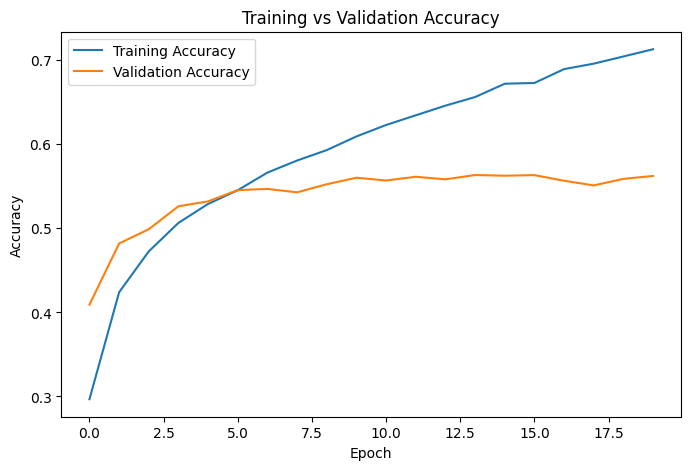

In [ ]:
plt.figure(figsize=(8,5))

plt.plot(
    history.history["accuracy"],
    label="Training Accuracy"
)

plt.plot(
    history.history["val_accuracy"],
    label="Validation Accuracy"
)

plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Training vs Validation Accuracy")

plt.legend()

plt.show()

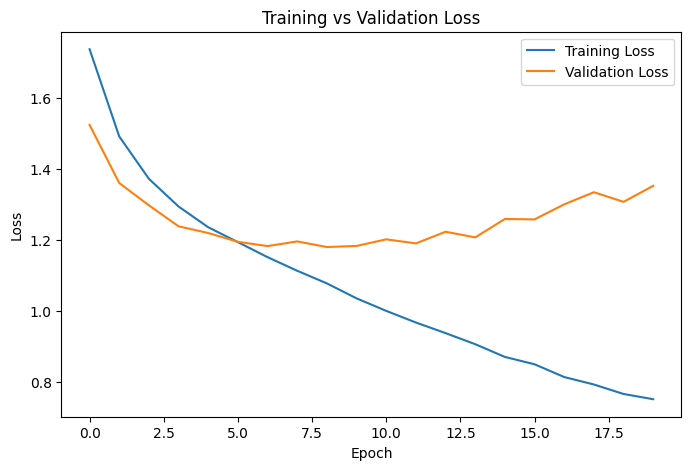

In [ ]:
plt.figure(figsize=(8,5))

plt.plot(
    history.history["loss"],
    label="Training Loss"
)

plt.plot(
    history.history["val_loss"],
    label="Validation Loss"
)

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training vs Validation Loss")

plt.legend()

plt.show()

In [ ]:
test_loss, test_accuracy = model.evaluate(test_dataset)

print("Test Accuracy :", round(test_accuracy*100,2),"%")

225/225 [==============================] - 14s 62ms/step - loss: 1.3530 - accuracy: 0.5624
Test Accuracy : 56.24 %


In [ ]:
model.save("../models/emotion_model.keras")

print("Model Saved Successfully!")

Model Saved Successfully!


# Training Summary

Completed:

- Trained CNN Model
- Evaluated Model
- Plotted Accuracy Curve
- Plotted Loss Curve
- Saved Trained Model

## End of Notebook